<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/FFT_wav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, we need to import the necessary libraries to handle the audio file and plotting.

In [2]:
import requests
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import os

Downloaded to downloaded_audio.wav
Audio cropped from 0 to 112676 samples.


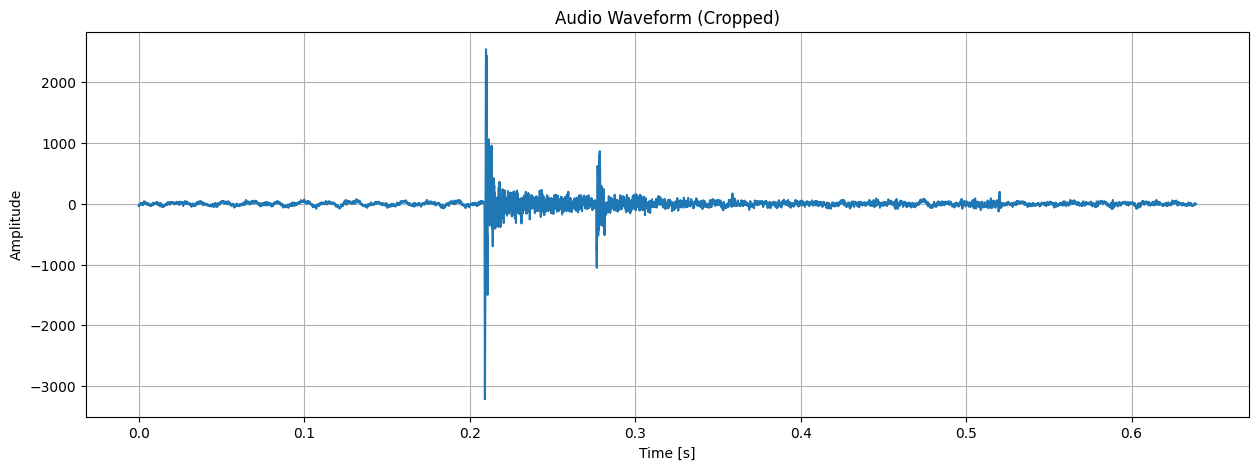

In [7]:
# Replace this with the direct URL to your .wav file on GitHub
wav_file_url = 'https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/glock3_ch0.wav'
local_filename = 'downloaded_audio.wav'

# Check if the URL is provided
if wav_file_url == 'YOUR_GITHUB_RAW_WAV_FILE_URL_HERE':
    print("Please provide the direct URL to your WAV file from GitHub in the 'wav_file_url' variable.")
else:
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url}...")
        response = requests.get(wav_file_url)
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_filename}")

        # Read the WAV file
        samplerate, data = wavfile.read(local_filename)

        # If stereo, take one channel for plotting
        if data.ndim > 1:
            data = data[:, 0] # Take the first channel

        # --- Cropping the WAV data ---
        total_samples = len(data)
        start_index = int(total_samples * 0.0)
        end_index = int(total_samples * 1.0)
        data = data[start_index:end_index]
        print(f"Audio cropped from {start_index} to {end_index} samples.")
        # ------------------------------

        # Create a time array for the x-axis for the (possibly cropped) data
        time = np.linspace(0., len(data) / samplerate, len(data))

        # Plot the waveform
        plt.figure(figsize=(15, 5))
        plt.plot(time, data)
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
        plt.title("Audio Waveform (Cropped)")
        plt.grid(True)
        plt.show()

        # Optional: Remove the downloaded file after processing
        # os.remove(local_filename)
        # print(f"Removed temporary file: {local_filename}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_filename}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Now, let's perform a Fast Fourier Transform (FFT) on the audio data to analyze its frequency content.

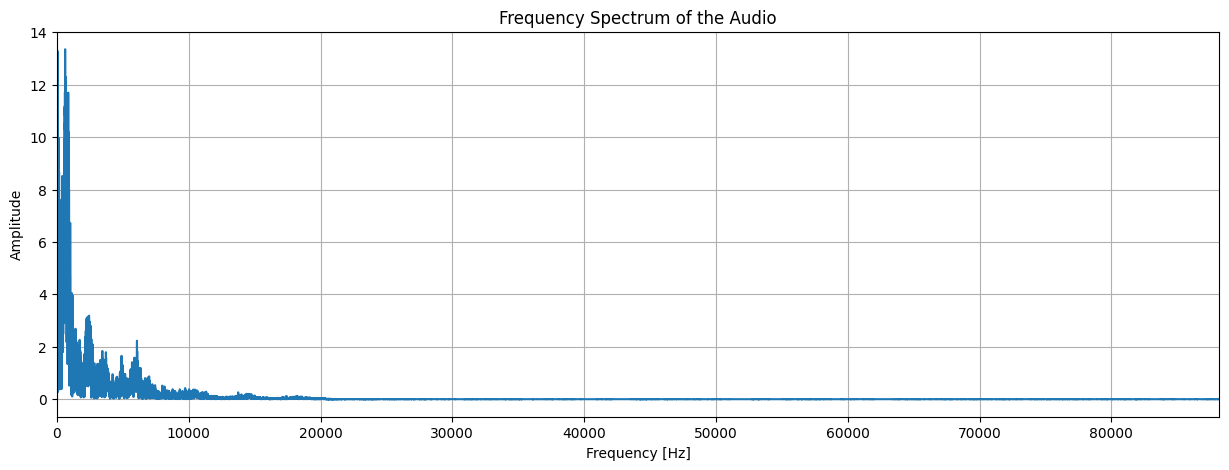

In [8]:
from scipy.fft import fft, fftfreq

# Perform FFT
N = len(data) # Number of sample points
T = 1.0 / samplerate # Sample spacing

yf = fft(data)
xf = fftfreq(N, T)[:N//2]

# Plot the frequency spectrum
plt.figure(figsize=(15, 5))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of the Audio")
plt.grid(True)
plt.xlim(0, samplerate / 2) # Show frequencies up to Nyquist frequency
plt.show()

New audio data cropped from 28169 to 84507 samples.


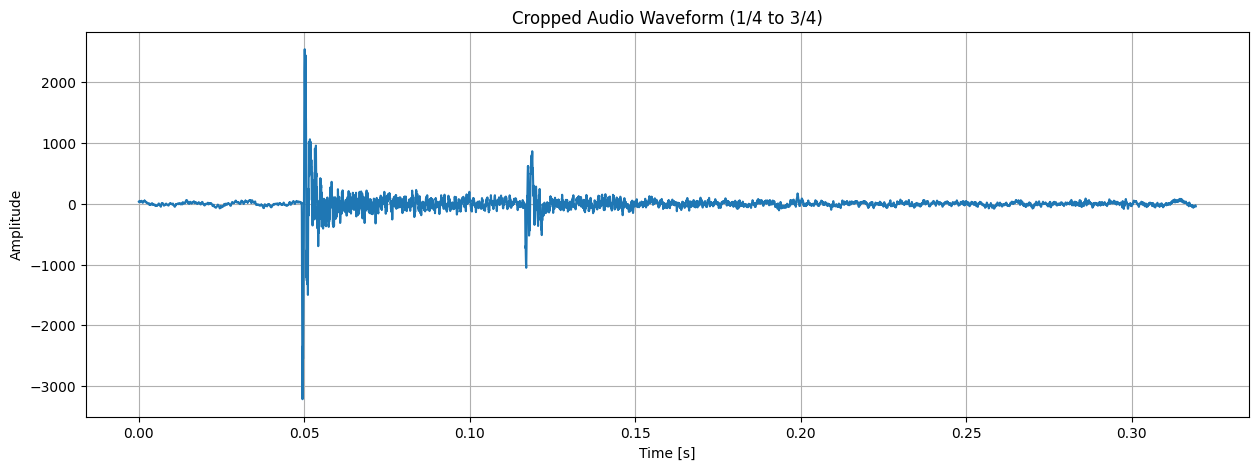

In [9]:
# Create a cropped version of the audio data
cropped_total_samples = len(data)
cropped_start_index = int(cropped_total_samples * 0.25)
cropped_end_index = int(cropped_total_samples * 0.75)

cropped_data = data[cropped_start_index:cropped_end_index]
print(f"New audio data cropped from {cropped_start_index} to {cropped_end_index} samples.")

# Create a time array for the cropped data
cropped_time = np.linspace(0., len(cropped_data) / samplerate, len(cropped_data))

# Plot the cropped waveform
plt.figure(figsize=(15, 5))
plt.plot(cropped_time, cropped_data)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Cropped Audio Waveform (1/4 to 3/4)")
plt.grid(True)
plt.show()

Now, let's perform the FFT on the newly cropped audio data to see its frequency spectrum.

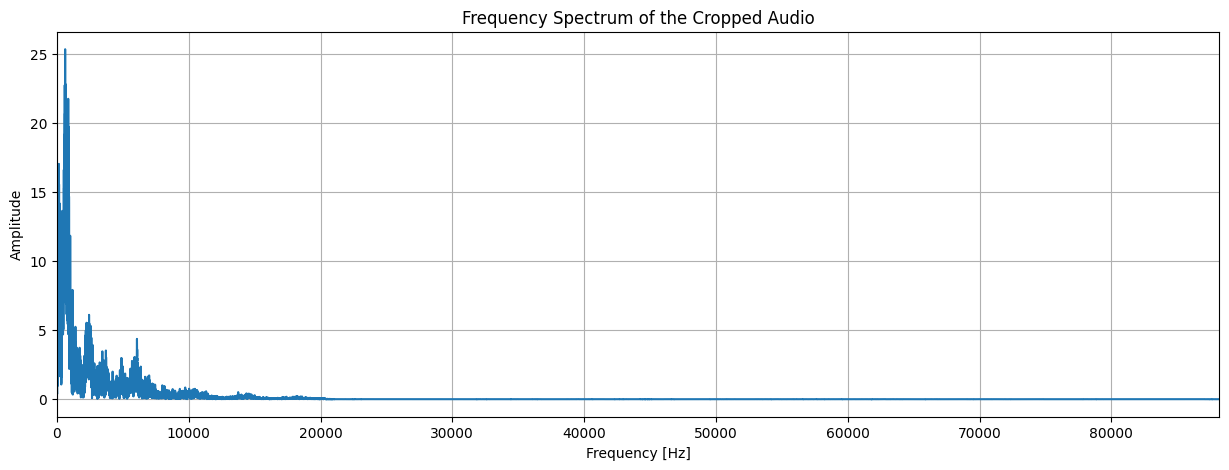

In [10]:
from scipy.fft import fft, fftfreq

# Perform FFT on the cropped data
N_cropped = len(cropped_data) # Number of sample points for cropped data
T_cropped = 1.0 / samplerate # Sample spacing is the same

yf_cropped = fft(cropped_data)
xf_cropped = fftfreq(N_cropped, T_cropped)[:N_cropped//2]

# Plot the frequency spectrum of the cropped data
plt.figure(figsize=(15, 5))
plt.plot(xf_cropped, 2.0/N_cropped * np.abs(yf_cropped[0:N_cropped//2]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of the Cropped Audio")
plt.grid(True)
plt.xlim(0, samplerate / 2) # Show frequencies up to Nyquist frequency
plt.show()